     Policy  TotalCost  OrderCost  HoldingCost  ShortageCost
0   (20,40)     123.48     105.02        12.02          6.45
1   (20,60)     119.92      95.64        22.15          2.13
2   (20,80)     118.10      83.42        33.58          1.10
3  (20,100)     125.63      83.20        41.58          0.85
4   (40,60)     134.94     102.04        32.81          0.09
5   (40,80)     135.70      94.65        41.05          0.00
6  (40,100)     140.54      89.09        51.41          0.03
7   (60,80)     159.16     108.91        50.25          0.00
8  (60,100)     157.71      96.19        61.52          0.00


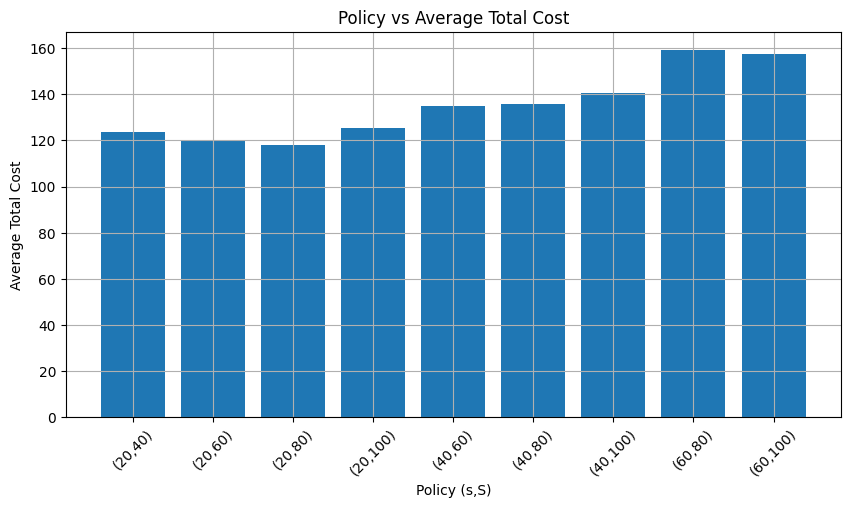

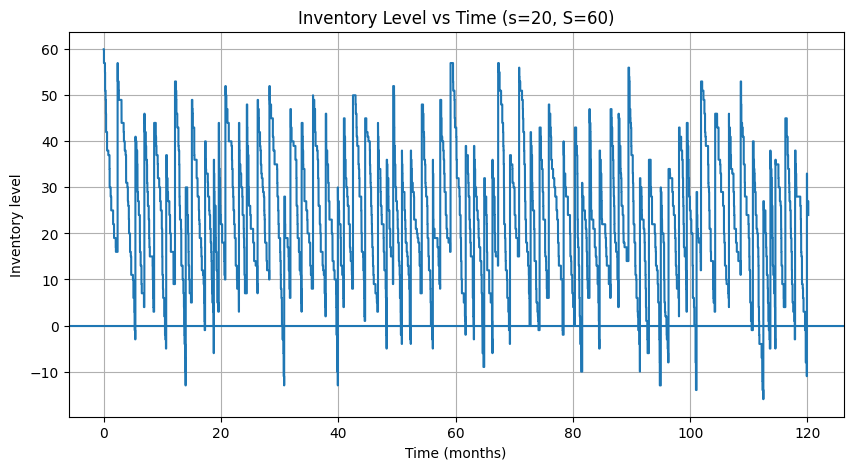

(116.78382533751974, 92.06666666666666, 23.45632558776536, 1.2608330830877295)

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SIM_TIME = 120

K = 32.0
i = 3.0
h = 1.0
p = 5.0

INIT_INVENTORY = 60

DEMAND_SIZES = [1, 2, 3, 4]
DEMAND_WEIGHTS = [1/6, 1/3, 1/3, 1/6]

MEAN_INTERDEMAND = 0.10
LEAD_TIME_MIN = 0.5
LEAD_TIME_MAX = 1.0

policies = [
    (20, 40), (20, 60), (20, 80), (20, 100),
    (40, 60), (40, 80), (40, 100),
    (60, 80), (60, 100)
]

def demand_size():
    return random.choices(DEMAND_SIZES, weights=DEMAND_WEIGHTS)[0]

def simulate_policy(s, S, plot=False):
    inventory = INIT_INVENTORY
    outstanding_order = 0
    order_arrival_time = None
    time = 0.0

    area_holding = 0.0
    area_backlog = 0.0
    total_order_cost = 0.0

    time_points = [0.0]
    inventory_levels = [inventory]

    while time < SIM_TIME:

        time_to_demand = np.random.exponential(MEAN_INTERDEMAND)
        next_demand_time = time + time_to_demand

        if order_arrival_time is not None:
            next_event_time = min(next_demand_time, order_arrival_time)
        else:
            next_event_time = next_demand_time

        holding = max(inventory, 0)
        backlog = max(-inventory, 0)

        area_holding += holding * (next_event_time - time)
        area_backlog += backlog * (next_event_time - time)

        time = next_event_time

        if order_arrival_time == time:
            inventory += outstanding_order
            outstanding_order = 0
            order_arrival_time = None
        else:
            inventory -= demand_size()

        if outstanding_order == 0 and inventory < s:
            Z = S - inventory
            total_order_cost += K + i * Z
            lead_time = random.uniform(LEAD_TIME_MIN, LEAD_TIME_MAX)
            order_arrival_time = time + lead_time
            outstanding_order = Z

        time_points.append(time)
        inventory_levels.append(inventory)

    avg_holding_cost = h * area_holding / SIM_TIME
    avg_backlog_cost = p * area_backlog / SIM_TIME
    avg_order_cost = total_order_cost / SIM_TIME
    total_cost = avg_holding_cost + avg_backlog_cost + avg_order_cost

    if plot:
        plt.figure(figsize=(10,5))
        plt.step(time_points, inventory_levels, where="post")
        plt.axhline(0)
        plt.xlabel("Time (months)")
        plt.ylabel("Inventory level")
        plt.title(f"Inventory Level vs Time (s={s}, S={S})")
        plt.grid(True)
        plt.show()

    return total_cost, avg_order_cost, avg_holding_cost, avg_backlog_cost


results = []

for s, S in policies:
    total_c, order_c, hold_c, back_c = simulate_policy(s, S)
    results.append([f"({s},{S})", total_c, order_c, hold_c, back_c])

df = pd.DataFrame(results,
    columns=["Policy", "TotalCost", "OrderCost", "HoldingCost", "ShortageCost"])

print(df.round(2))


plt.figure(figsize=(10,5))
plt.bar(df["Policy"], df["TotalCost"])
plt.xlabel("Policy (s,S)")
plt.ylabel("Average Total Cost")
plt.title("Policy vs Average Total Cost")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


simulate_policy(20, 60, plot=True)
